In [1]:
#Import libraries 
import pandas as pd
import numpy as np
import requests
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt


import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import re
import random

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

### Open full monster stat csv

In [2]:
mon_data= pd.read_csv('../build data/monster_data_short.csv').dropna(how='all')
mon_data.head(3)

,name,Rarity,Alignment,Creature Level,Trait 1,Trait 2,Trait 3,Trait 4,Trait 5,Trait 6,...,dmg_Bleed,dmg_Lawful,dmg_Chaotic,dmg_Good,dmg_Evil,dmg_Magical,Reaction 1,Reaction 2,Reaction 3,Attack Op
0,ABANDONED ZEALOT,Common,Chaotic Evil,6,Incorporeal,Spirit,Undead,NaN,NaN,NaN,...,False,False,False,False,False,True,"Elegy of the Faithless (abjuration, magical tr...",NaN,NaN,False
1,ADLET,Common,Chaotic Neutral,10,Cold,Humanoid,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,Avenging Bite Trigger A creature within reach ...,NaN,NaN,False
2,ARBITER,Common,Neutral,1,Aeon,Inevitable,Monitor,NaN,NaN,NaN,...,False,True,False,False,False,True,NaN,NaN,NaN,False


In [3]:
col_list= mon_data.columns.to_list()
attack_col = [x for x in col_list if 'attack' in x.lower()]
spell_col = [x for x in col_list if 'spell' in x.lower() or 'spatk' in x.lower()]
move_col= [x for x in col_list if 'speed' in x.lower()]
trait_col= [x for x in col_list if 'trait' in x.lower()]

col_list

stat_col = ['Creature Level', 
 'Perception',
 'HP',
 'AC',
 'Fort',
 'Ref',
 'Will',
 'Fort DC',
 'Ref DC',
 'Will DC']

In [248]:
damage_type_list=['bludgeoning', 
                  'piercing', 
                  'slashing', 
                  'bleed', 
                  'acid', 
                  'cold', 
                  'electricity', 
                  'fire', 
                  'sonic',  
                  'force', 
                  'chaotic', 
                  'evil', 
                  'good', 
                  'lawful', 
                  'spirit',
                  'vitality', 
                  'void', 
                  'mental', 
                  'precision', 
                 'varies']

attack_category_list= ['melee', 'range', 'ranged']

other_mechanic_list = ['reload']

def find_damage_die(attack_text):
    pattern = r"(\d+)d(\d+)([+\-]\d+)"
    pattern_1 = r"(\d+)d(\d+)$"
    #set defaults 
    num_dice=0
    dmg_dice=0
    dmg_mod=0
    
    #save it to a final list for duplicated
    dmg_dice_list=[]
    
    #check if there is damage description in the text and then pull out the damage information 
    if 'damage' in attack_text.lower():
        for text in attack_text.split():
            match = re.match(pattern, text)
            if match:
                num_dice= match.group(1)
                #print(num_dice)
                dmg_dice= match.group(2)
                #print(dmg_dice)
                dmg_mod= match.group(3).replace('+', '')
                #print(dmg_mod)
                dmg_dice_list.append([num_dice, dmg_dice, dmg_mod])
    
            #check for a second match
            match = re.match(pattern_1, text)
            if match:
                num_dice= match.group(1)
                #print(num_dice)
                dmg_dice= match.group(2)
                #print(dmg_dice)
                dmg_mod= 0
                #print(dmg_mod)
                dmg_dice_list.append([num_dice, dmg_dice, dmg_mod])
    return dmg_dice_list

def get_attack_info(series, attack_col):
    mon_choice = series
    attack_info_list= []
    ### pull out the necessary filters from the attack descriptions 
    for col_num, col_value in enumerate(attack_col):
        attack_text = mon_choice[attack_col[col_num]]
        #check if the text is actually a number- then skip
        if attack_text!='0' and attack_text is not None and attack_text!='nan' and isinstance(attack_text, str):
            #print(f"{col_value}:", attack_text)
            #attack name: assuming it is always second 
            attack_name= attack_text.split()[1]
            #print('attack name', attack_name)
            
            #check damage type list for the type
            damage_type = set([x if x in attack_text.lower() else 0 for x in damage_type_list])
            damage_type.discard(0) #remove the filler 
            damage_type= list(damage_type) #convert set to list for easier processing
            #print('damage', damage_type)
            
            #attack category from the list
            attack_cat = attack_category_list[[x in attack_text.lower() for x in attack_category_list].index(True)]
            
            #set default for range and action cost
            action_cost=1
            range_ft=5
            
            #add extra information if the attack is a ranged attack
            if attack_cat == 'range':
                #Find the range attack value
                match = re.search(r"(\d+) feet", attack_text)
                if match:
                    range_ft = match.group(1)

                #Account for any text that is in 'ft'
                match = re.search(r"(\d+) ft", attack_text)
                if match:
                    range_ft = match.group(1)
            
                #check if it needs reload 
                if 'reload' in attack_text:
                    #add it as an extra cost for the action if it includes reload
                    action_cost+=1
            #print(range_ft, action_cost)
            #print('category', attack_cat)
            
            #damage calculations 
            dmg_dice_list = find_damage_die(attack_text)
            #print(f'{num_dice}d{dmg_dice} {dmg_mod}')
            
            #attack modifier is stored in the next column 
            attack_mod=mon_choice[attack_col[col_num+1]]
            #print('attack modifier', attack_mod)
        
            #save information to dictionary 
            attack_info = {'monster_name': mon_choice['name'], 
                           'monster_level': mon_choice['Creature Level'],
                           'attack_number': col_value,
                           'name' :attack_name, 
                           'damage type': damage_type, 
                           'attack_range': range_ft,
                           'action_cost': action_cost,
                           'category': attack_cat, 
                           'dmg_dice_formula': dmg_dice_list, 
                           'attack_roll_mod': attack_mod}
            attack_info_list.append(list(attack_info.values()))
    return attack_info_list

## Filter out other attack information
* Also need to update range and cooldown informaiton, and any status effect to attack

## Pull out information for all attacks 

In [249]:
#Iterate between each monster row and pull out information for physical attacks

all_mon_attack_list= []
for mon_num in range(len(mon_data)):
    #pull out series for specific monster of interest
    mon_choice = mon_data.iloc[mon_num]
    #Run through function to analyze physcial attack actions
    physical_attack_list= get_attack_info(mon_choice, attack_col)

    #save the processes data to a list of lists
    all_mon_attack_list.extend(physical_attack_list)

len(all_mon_attack_list)

5228

### Create a dataframe with each attack action from the attack list analysis

In [262]:
## setup final dataframe 
df_col_name= ['monster_name', 'monster_level', 
              'action_term', 'action_name', 'damage_type', 'attack_range', 'action_cost', 'attack_type', 'damage_dice_calculations', 'attack_roll_mod']

monster_action_list= pd.DataFrame(all_mon_attack_list, columns=df_col_name)

#drop any attack that do not have an attack_roll_mod number to clean up incorrect errors
monster_action_list= monster_action_list.dropna(subset=['attack_roll_mod'])

#drop any attacks that do not have a damage dice calculation
monster_action_list= monster_action_list[(monster_action_list['damage_dice_calculations'].str.len()!=0)]

#view final action dataframe
monster_action_list

#Save the final action dataframe to the data folder 
monster_action_list.to_csv('../build data/all_monster_attack_list.csv')

## Visualize the distribution of monster levels with actions 

array([[<Axes: title={'center': 'monster_level'}>]], dtype=object)

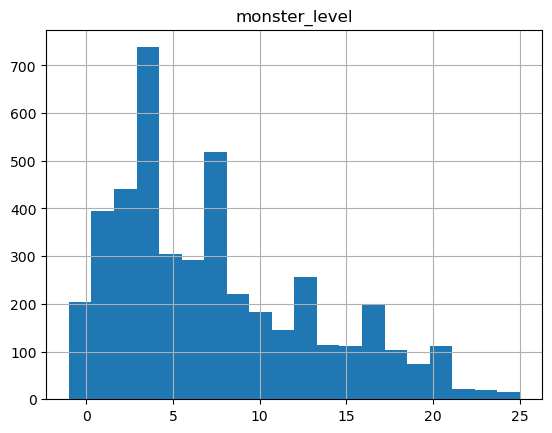

In [240]:
monster_action_list.hist('monster_level', bins=20)

## Visualize the total number of actions per monster

(array([653., 822., 422., 177.,  18.,  10.,   1.,   2.,   1.,   1.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

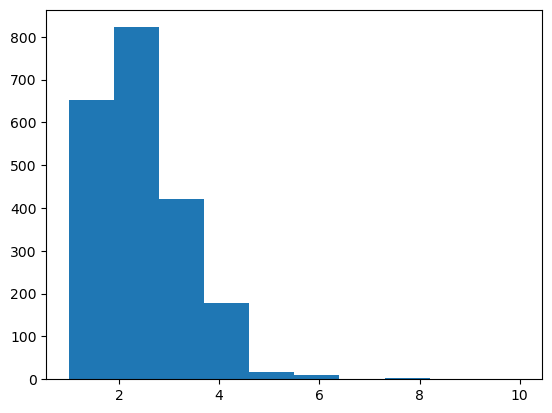

In [260]:
plt.hist(monster_action_list.groupby('monster_name')['action_name'].count().sort_values(ascending=False), bins=10)

## Check for possible data errors 

### All ranged attacks should have an attack range larger than 5ft

In [251]:
monster_action_list[monster_action_list['attack_type']=='range']['attack_range'].value_counts()

attack_range
60     175
10     152
30     149
20     142
120    104
100     68
50      38
5       27
80      14
40      10
200      7
15       4
150      3
90       3
300      2
70       1
75       1
500      1
180      1
5        1
Name: count, dtype: int64

In [266]:
monster_action_list[(monster_action_list['attack_type']=='range') & (monster_action_list['attack_range'] == 5)]

,monster_name,monster_level,action_term,action_name,damage_type,attack_range,action_cost,attack_type,damage_dice_calculations,attack_roll_mod
126,arboreal reaper,7,Attack 3,thorns,"[bleed, piercing]",5,1,range,"[[2, 8, 5], [1, 4, 0]]",16.0
246,flaming skull,2,Attack 2,spitfire,[fire],5,1,range,"[[1, 12, 2]]",10.0
617,dragon's blood puffball,8,Attack 1,bloom,[bludgeoning],5,1,range,"[[2, 10, 8], [1, 6, 0]]",18.0
1500,gliminal,9,Attack 2,radiant,[],5,1,range,"[[4, 8, 0]]",19.0
1633,blood hag,8,Attack 3,firebolt,[fire],5,1,range,"[[2, 10, 8]]",19.0
2090,grunka,-1,Attack 3,lesser,[fire],5,1,range,"[[1, 8, 0]]",8.0
2099,mercenary,-1,Attack 4,crossbow,[piercing],5,1,range,"[[1, 8, 0]]",4.0
2110,pelmo,-1,Attack 3,lesser,[fire],5,1,range,"[[1, 8, 0]]",8.0
2192,cheel,1,Attack 2,lesser,[fire],5,1,range,"[[1, 8, 0]]",9.0
2210,experienced mercenary,1,Attack 4,crossbow,[piercing],5,1,range,"[[1, 8, 0]]",5.0


In [276]:
print(mon_data[mon_data['name'] == 'vigilant guard']['Attack 2'])

1086    Ranged longsword +10 (versatile P), Damage 1d8...
Name: Attack 2, dtype: object


There are atleast 28 incorrectly text-processed range attacks 

In [265]:
monster_action_list[monster_action_list['monster_name'] == 'guard']

,monster_name,monster_level,action_term,action_name,damage_type,attack_range,action_cost,attack_type,damage_dice_calculations,attack_roll_mod
2091,guard,-1,Attack 1,spear,[piercing],5,1,melee,"[[1, 6, 2]]",6.0
2092,guard,-1,Attack 2,spear,[piercing],20,1,range,"[[1, 6, 2]]",6.0
2218,guard,1,Attack 1,club,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
2219,guard,1,Attack 2,sap,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
2220,guard,1,Attack 3,crossbow,[piercing],120,2,range,"[[1, 8, 0]]",7.0
2221,guard,1,Attack 4,club,[bludgeoning],10,1,range,"[[1, 6, 4]]",7.0
3782,guard,1,Attack 1,club,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
3783,guard,1,Attack 2,sap,[bludgeoning],5,1,melee,"[[1, 6, 4]]",9.0
3784,guard,1,Attack 3,crossbow,[piercing],120,2,range,"[[1, 8, 0]]",7.0
3785,guard,1,Attack 4,club,[bludgeoning],10,1,range,"[[1, 6, 4]]",7.0


----

### open all spell information data

In [7]:
spell_data= pd.read_csv('../raw data/spell_list.csv').dropna(how='all').dropna(axis=1, how='all')
spell_data.head(3)

,name,school,subschool,descriptor,spell_level,casting_time,components,costly_components,range,area,...,bloodrager,shaman,psychic,medium,mesmerist,occultist,spiritualist,summoner unchained,linktext.1,custom linktext
0,Acid Arrow,conjuration,creation,acid,"sorcerer/wizard 2, magus 2, bloodrager 2",1 standard action,"V, S, M (rhubarb leaf and an adder's stomach),...",0.0,long (400 ft. + 40 ft./level),NaN,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Acid Arrow,https://www.google.com/search?gfns=1&amp;sourc...
1,Acid Fog,conjuration,creation,acid,"sorcerer/wizard 6, magus 6, unchained summoner 6",1 standard action,"V, S, M (powdered peas and an animal hoof)",0.0,medium (100 ft. + 10 ft./level),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,Acid Fog,http://www.google.com/search?btnI=1&q=d20pfsrd...
2,Acid Splash,conjuration,creation,acid,"sorcerer/wizard 0, summoner/unchained summoner...",1 standard action,"V, S",0.0,close (25 ft. + 5 ft./2 levels),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Acid Splash,NaN


### pull out list of all spell names to use as a reference for spell actions

In [8]:
all_spell_list = spell_data['name'].unique().tolist()
all_spell_list= [x.lower() for x in all_spell_list]
len(all_spell_list)

2906

## Pull out spell attack information from monster list

In [143]:
mon_data['name']= mon_data['name'].str.lower()
mon_data[mon_data['name'] == 'water scamp']

## pull out the magical monster list 
mon_num = mon_data[mon_data['SPAtk 1'].notna()].iloc[50].name
mon_num

459

In [144]:
mon_choice = mon_data.iloc[459]
mon_choice

name                                             young magma dragon
Rarity                                                         Rare
Alignment                                           Chaotic Neutral
Creature Level                                                    9
Trait 1                                                      Dragon
                                        ...                        
dmg_Magical                                                   False
Reaction 1        Wing Deflection Trigger The dragon is targeted...
Reaction 2                                                      NaN
Reaction 3                                                      NaN
Attack Op                                                     False
Name: 459, Length: 83, dtype: object

In [11]:
### now check with spell list 
spell_col

['Spells 1',
 'spell1_mod',
 'Spells 2',
 'spell2_mod',
 'Spells 3',
 'spell3_mod',
 'SPAtk 1',
 'SPAtk 2',
 'SPAtk 3',
 'Max SPAtk']

In [12]:
spell_text= mon_choice[spell_col[0]]
spell_text.lower()

'primal innate spells dc 26, attack +18; 4th burning hands (at will); cantrips (5th) produce flame'

In [13]:
full_text = []
for col_num, col_value in enumerate(spell_col):
    spell_text= mon_choice[col_value]
    print(spell_text)

Primal Innate Spells DC 26, attack +18; 4th burning hands (at will); Cantrips (5th) produce flame
26.0
Primal Prepared Spells DC 28, attack +20; 4th stoneskin, wall of fire; 3rd haste, slow, stinking cloud; 2nd glitterdust, obscuring mist, restore senses; 1st air bubble, grease, pass without trace; Cantrips (4th) detect magic, prestidigitation, produce flame, read aura, tanglefoot
28.0
0
nan
18.0
20.0
nan
20.0


In [14]:
# round(mon_data.iloc[5]['Creature Level']/2)

In [15]:
# spell_text

# results = re.split(r'[;,]', spell_text)

# for text in results:
#     #remove any number information from string text 
#     clean_spell = re.sub(r'\d+th', '', text).lstrip()
    
#     if clean_spell in all_spell_list:
#         print(clean_spell)

TypeError: cannot use a string pattern on a bytes-like object

In [ ]:
# mon_choice = series
# attack_info_list= []
# ### pull out the necessary filters from the attack descriptions 
# for col_num, col_value in enumerate(attack_col):
#     attack_text = mon_choice[attack_col[col_num]]
#     #check if the text is actually a number- then skip
#     if attack_text!='0' and attack_text is not None and attack_text!='nan' and isinstance(attack_text, str):
#         #print(f"{col_value}:", attack_text)
#         #attack name: assuming it is always second 
#         attack_name= attack_text.split()[1]
#         #print('attack name', attack_name)
#         #check damage type list for the type
#         damage_type = damage_type_list[[x in attack_text.lower() for x in damage_type_list].index(True)]
#         #print('damage', damage_type)
        
#         #attack category from the list
#         attack_cat = attack_category_list[[x in attack_text.lower() for x in attack_category_list].index(True)]
#         #print('category', attack_cat)
        
#         #damage calculations 
#         num_dice, dmg_dice, dmg_mod = find_damage_die(attack_text)
#         #print(f'{num_dice}d{dmg_dice} {dmg_mod}')
        
#         #attack modifier is stored in the next column 
#         attack_mod= mon_data.iloc[100][attack_col[col_num+1]]
#         #print('attack modifier', attack_mod)

#         #save information to dictionary 
#         attack_info = {'attack_number': col_value,
#                        'name' :attack_name, 
#                        'damage type': damage_type, 
#                        'category': attack_cat, 
#                        'number_dmg_dice': num_dice, 
#                        'dmg_dice_type': dmg_dice,
#                        'additonal_dmg':dmg_mod,
#                        'attack_roll_mod': attack_mod}
#         attack_info_list.append(list(attack_info.values()))